Plot latest versions from Neonatal run against GBD

In [5]:
import pandas as pd
from db_queries import get_location_metadata
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import numpy as np
from matplotlib.ticker import MaxNLocator

In [2]:
# Set paths ####################################################################
GBD_FILE = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/input/gbd_prevalence/gbd_mean_neonatal_mortality_prevalence.parquet"
INFERENCE_FILE_08_03 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_08_03.03/ssp245.parquet"  # Previous most-recent run
INFERENCE_FILE_09_14 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_14.01/ssp245.parquet"  # Consumption merged on birth year
PLOT_OUTPUT = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/"

In [3]:
# Load and format ##############################################################
def get_mean_draw(data):
    draw_cols = [col for col in data.columns if col.startswith("draw_")]
    mean_draw = data[draw_cols].mean(axis=1)
    data_out = data[[col for col in data.columns if "draw_" not in col]]
    data_out["prevalence"] = mean_draw
    return data_out


gbd_df = (
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .rename(columns={"gbd_mean_prevalence": "prevalence"})
)

df_08_03 = (
    pd.read_parquet(INFERENCE_FILE_08_03)
    .reset_index()
    .drop(columns=["age_group_id", "scenario"])
)
df_09_14 = (
    pd.read_parquet(INFERENCE_FILE_09_14)
    .reset_index()
    .drop(columns=["age_group_id", "scenario"])
)

df_08_03 = get_mean_draw(df_08_03)
df_09_14 = get_mean_draw(df_09_14)


intersection_years = list(set(df_08_03["year_id"]).intersection(set(gbd_df["year_id"])))
df_08_03 = df_08_03[df_08_03["year_id"].isin(intersection_years)].reset_index(drop=True)
df_09_14 = df_09_14[df_09_14["year_id"].isin(intersection_years)].reset_index(drop=True)


gbd_df.rename(columns={"prevalence": "prevalence_gbd"}, inplace=True)
df_08_03.rename(columns={"prevalence": "prevalence_initial"}, inplace=True)
df_09_14.rename(
    columns={"prevalence": "prevalence_birth_year_consumption"}, inplace=True
)

merged_df = gbd_df.merge(df_08_03, on=["location_id", "year_id", "sex_id"], how="left")
merged_df = merged_df.merge(
    df_09_14, on=["location_id", "year_id", "sex_id"], how="left"
)


# Add location names
locs = get_location_metadata(location_set_id=39, release_id=16)

merged_df = merged_df.merge(
    locs[["location_id", "location_name", "level", "super_region_name"]],
    on="location_id",
    how="left",
)

/tmp/ipykernel_1198362/1216602279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out["prevalence"] = mean_draw
/tmp/ipykernel_1198362/1216602279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_out["prevalence"] = mean_draw


In [4]:
plot_df = merged_df[
    (merged_df["super_region_name"] == "Sub-Saharan Africa")
    & (merged_df["year_id"].isin(intersection_years))
    & (merged_df["level"] == 3)
]
plot_df.head()

,location_id,year_id,age_group_id,sex_id,prevalence_gbd,prevalence_initial,prevalence_birth_year_consumption,location_name,level,super_region_name
92665,168,2000,42,1,0.037360,0.021877,0.022535,Angola,3.0,Sub-Saharan Africa
92666,169,2000,42,1,0.045624,0.029834,0.029697,Central African Republic,3.0,Sub-Saharan Africa
92667,170,2000,42,1,0.027920,0.022844,0.023311,Congo,3.0,Sub-Saharan Africa
92668,171,2000,42,1,0.033969,0.028450,0.028720,Democratic Republic of the Congo,3.0,Sub-Saharan Africa
92669,172,2000,42,1,0.038597,0.021119,0.021396,Equatorial Guinea,3.0,Sub-Saharan Africa


/tmp/ipykernel_1066232/2825811784.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Sex"] = plot_df["sex_id"].map(sex_id_dict)
Creating plot pages:   0%|          | 0/8 [00:00<?, ?it/s]

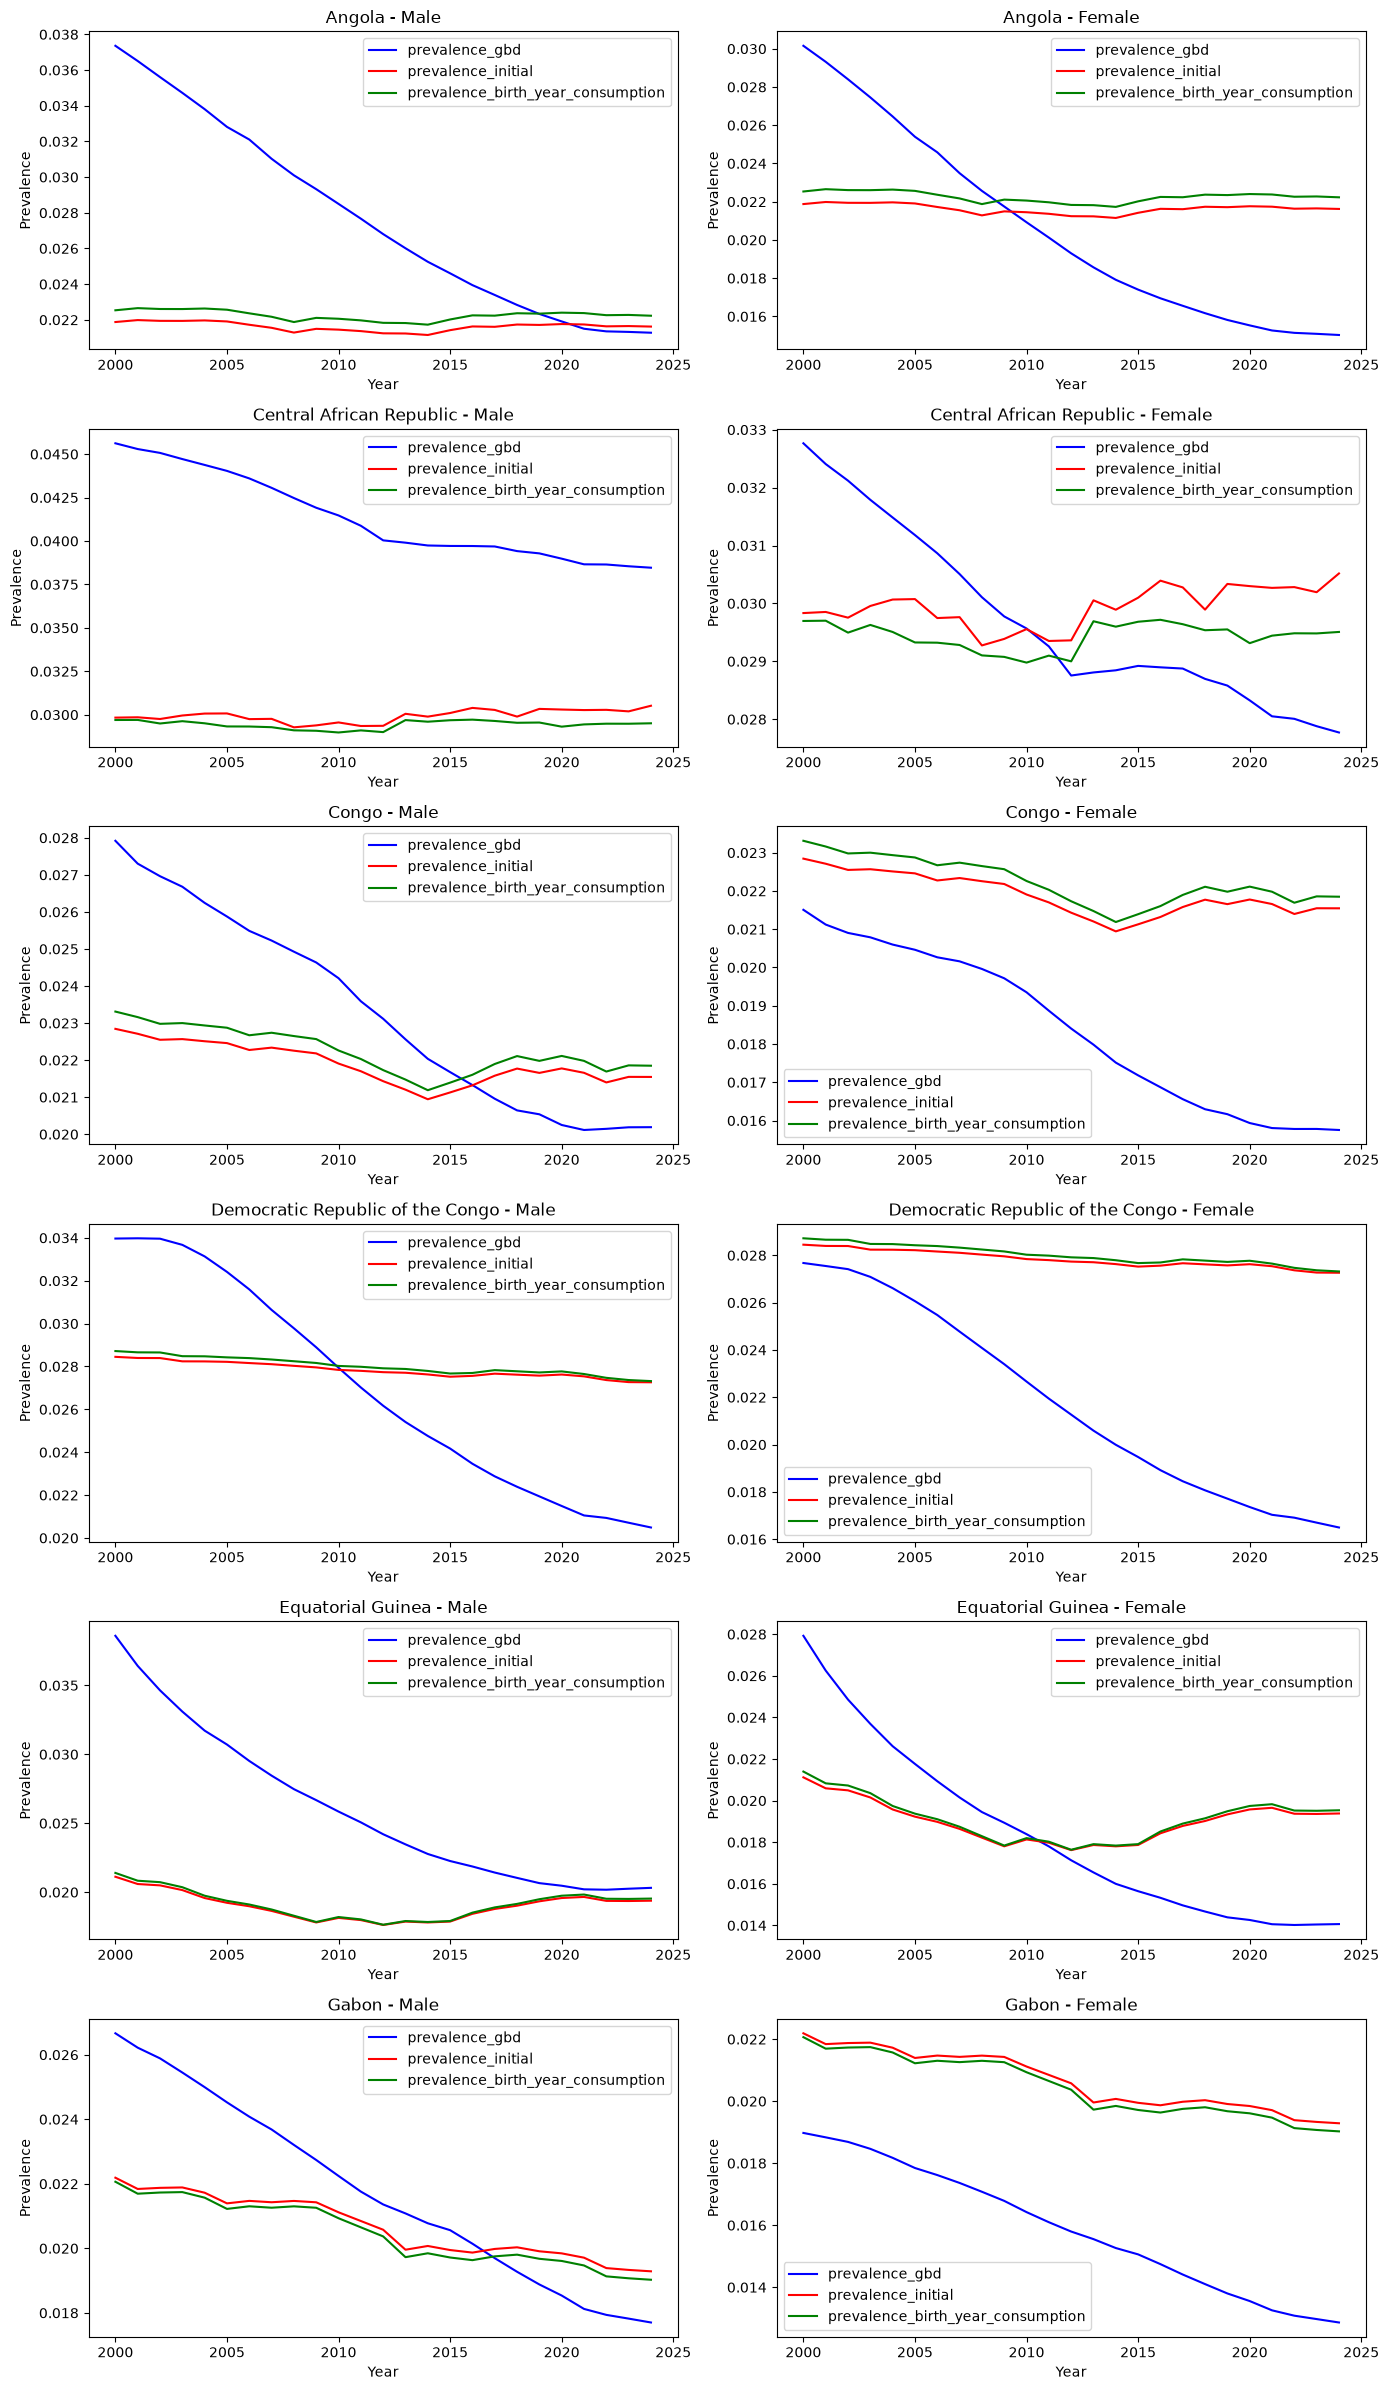

Creating plot pages:  12%|█▎        | 1/8 [00:02<00:17,  2.46s/it]

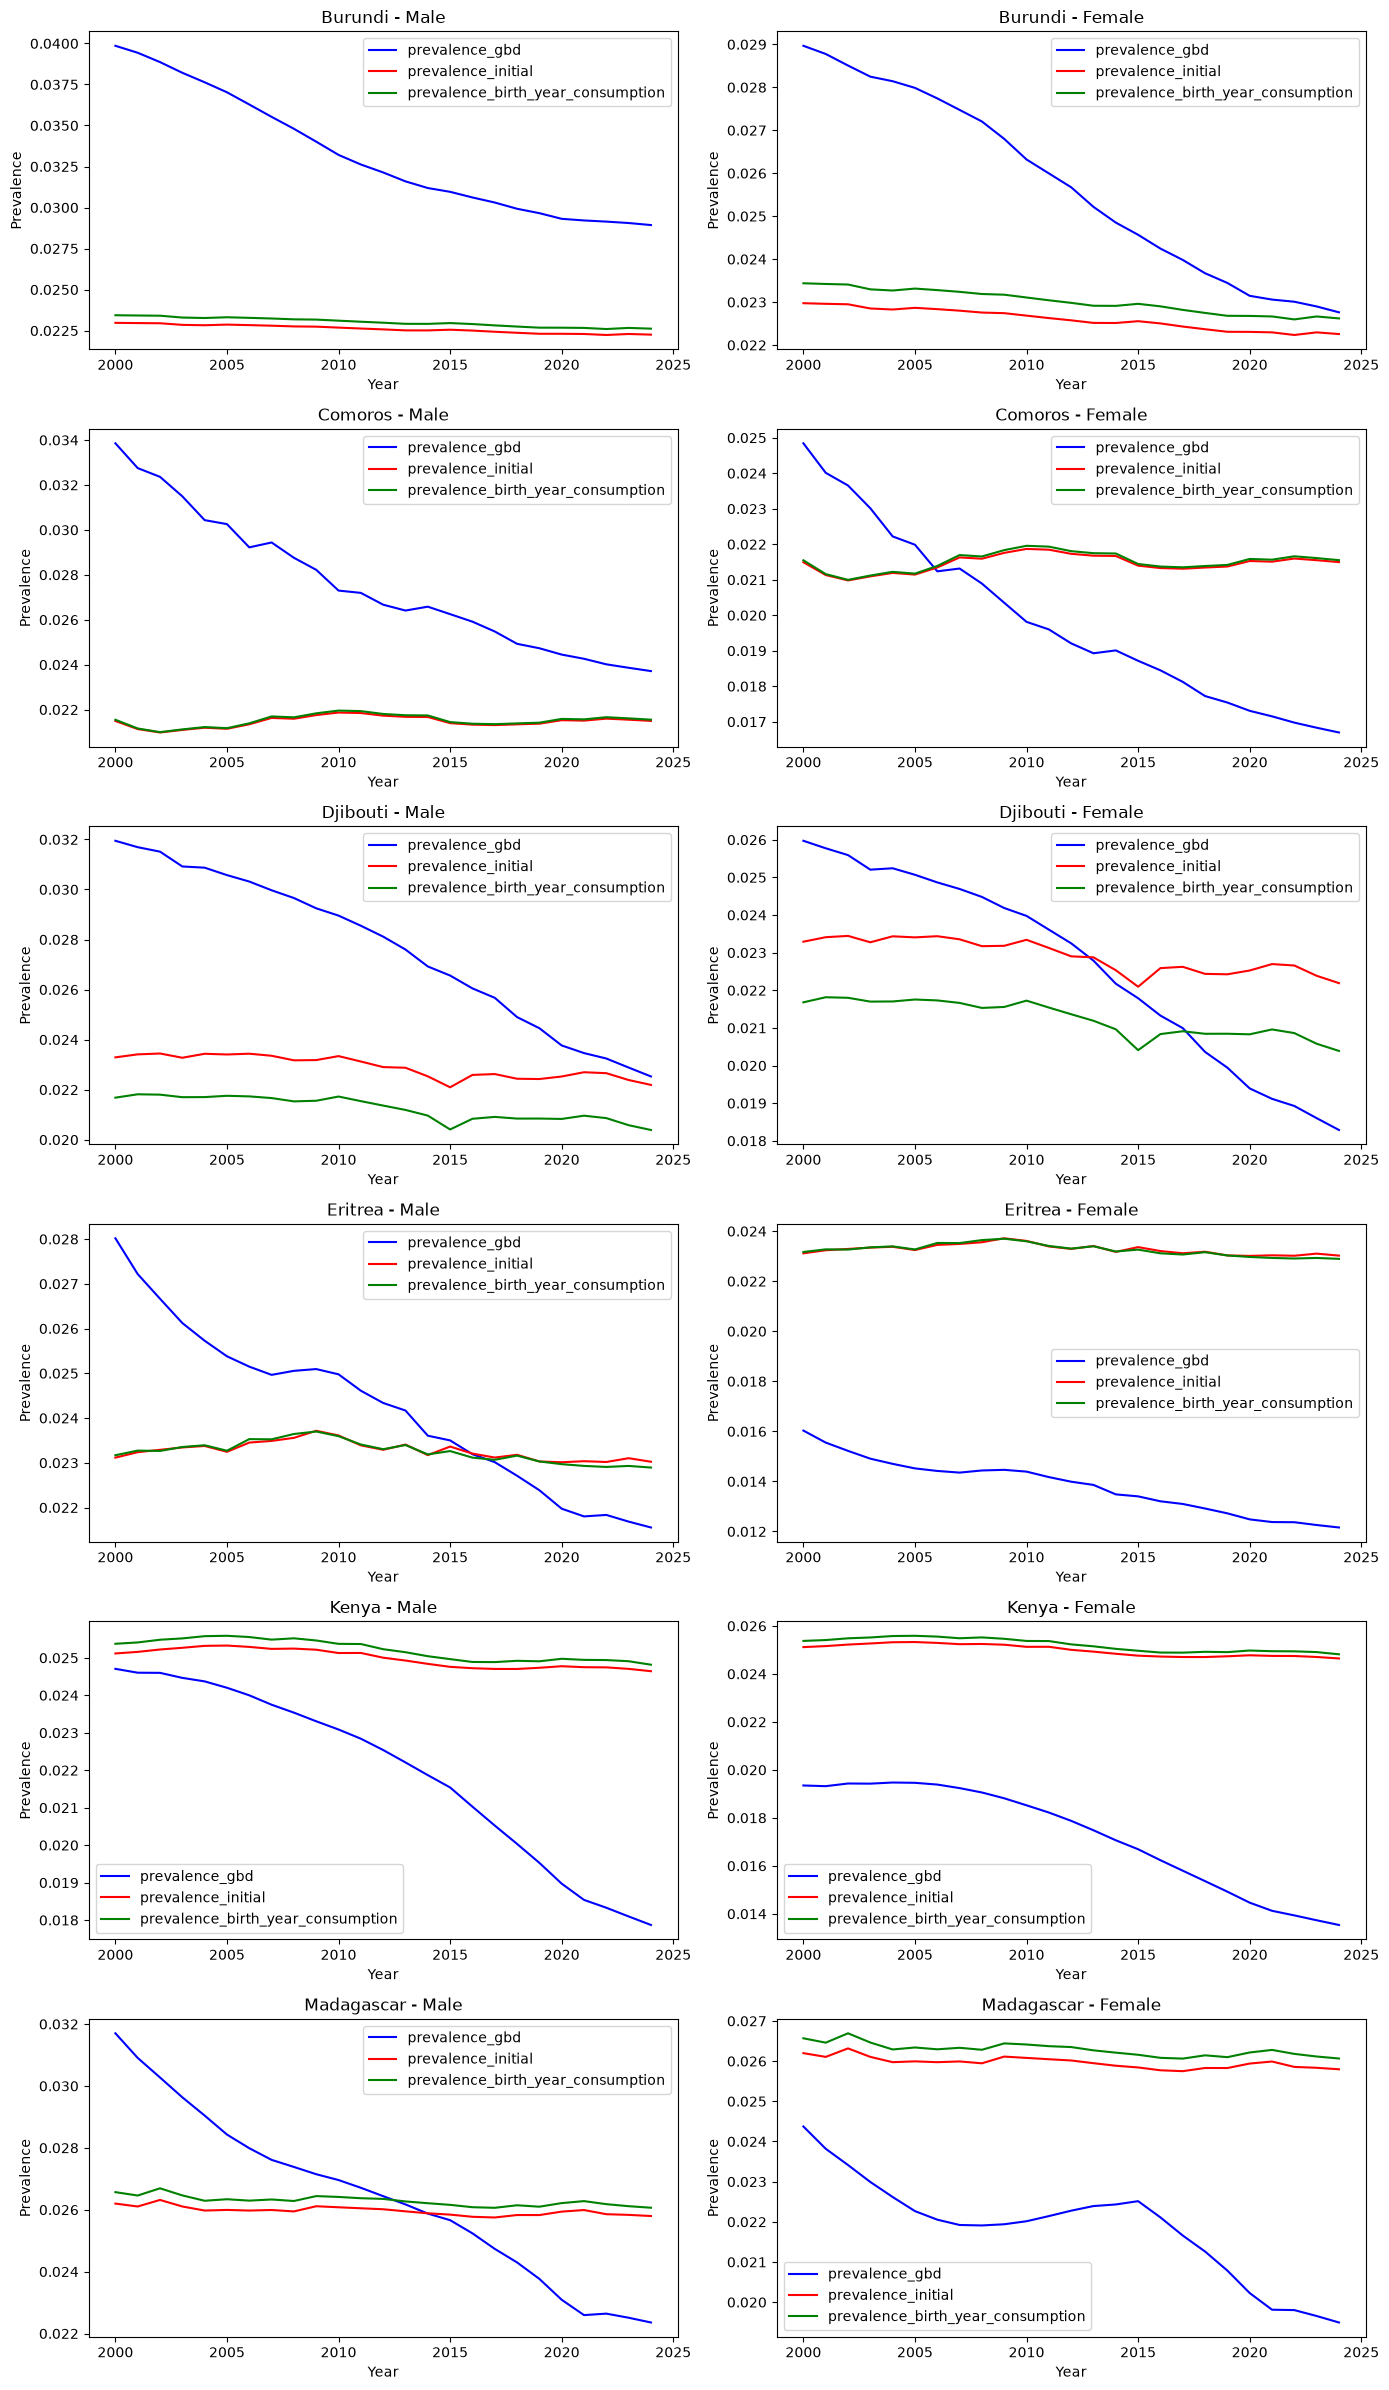

Creating plot pages:  25%|██▌       | 2/8 [00:04<00:13,  2.26s/it]

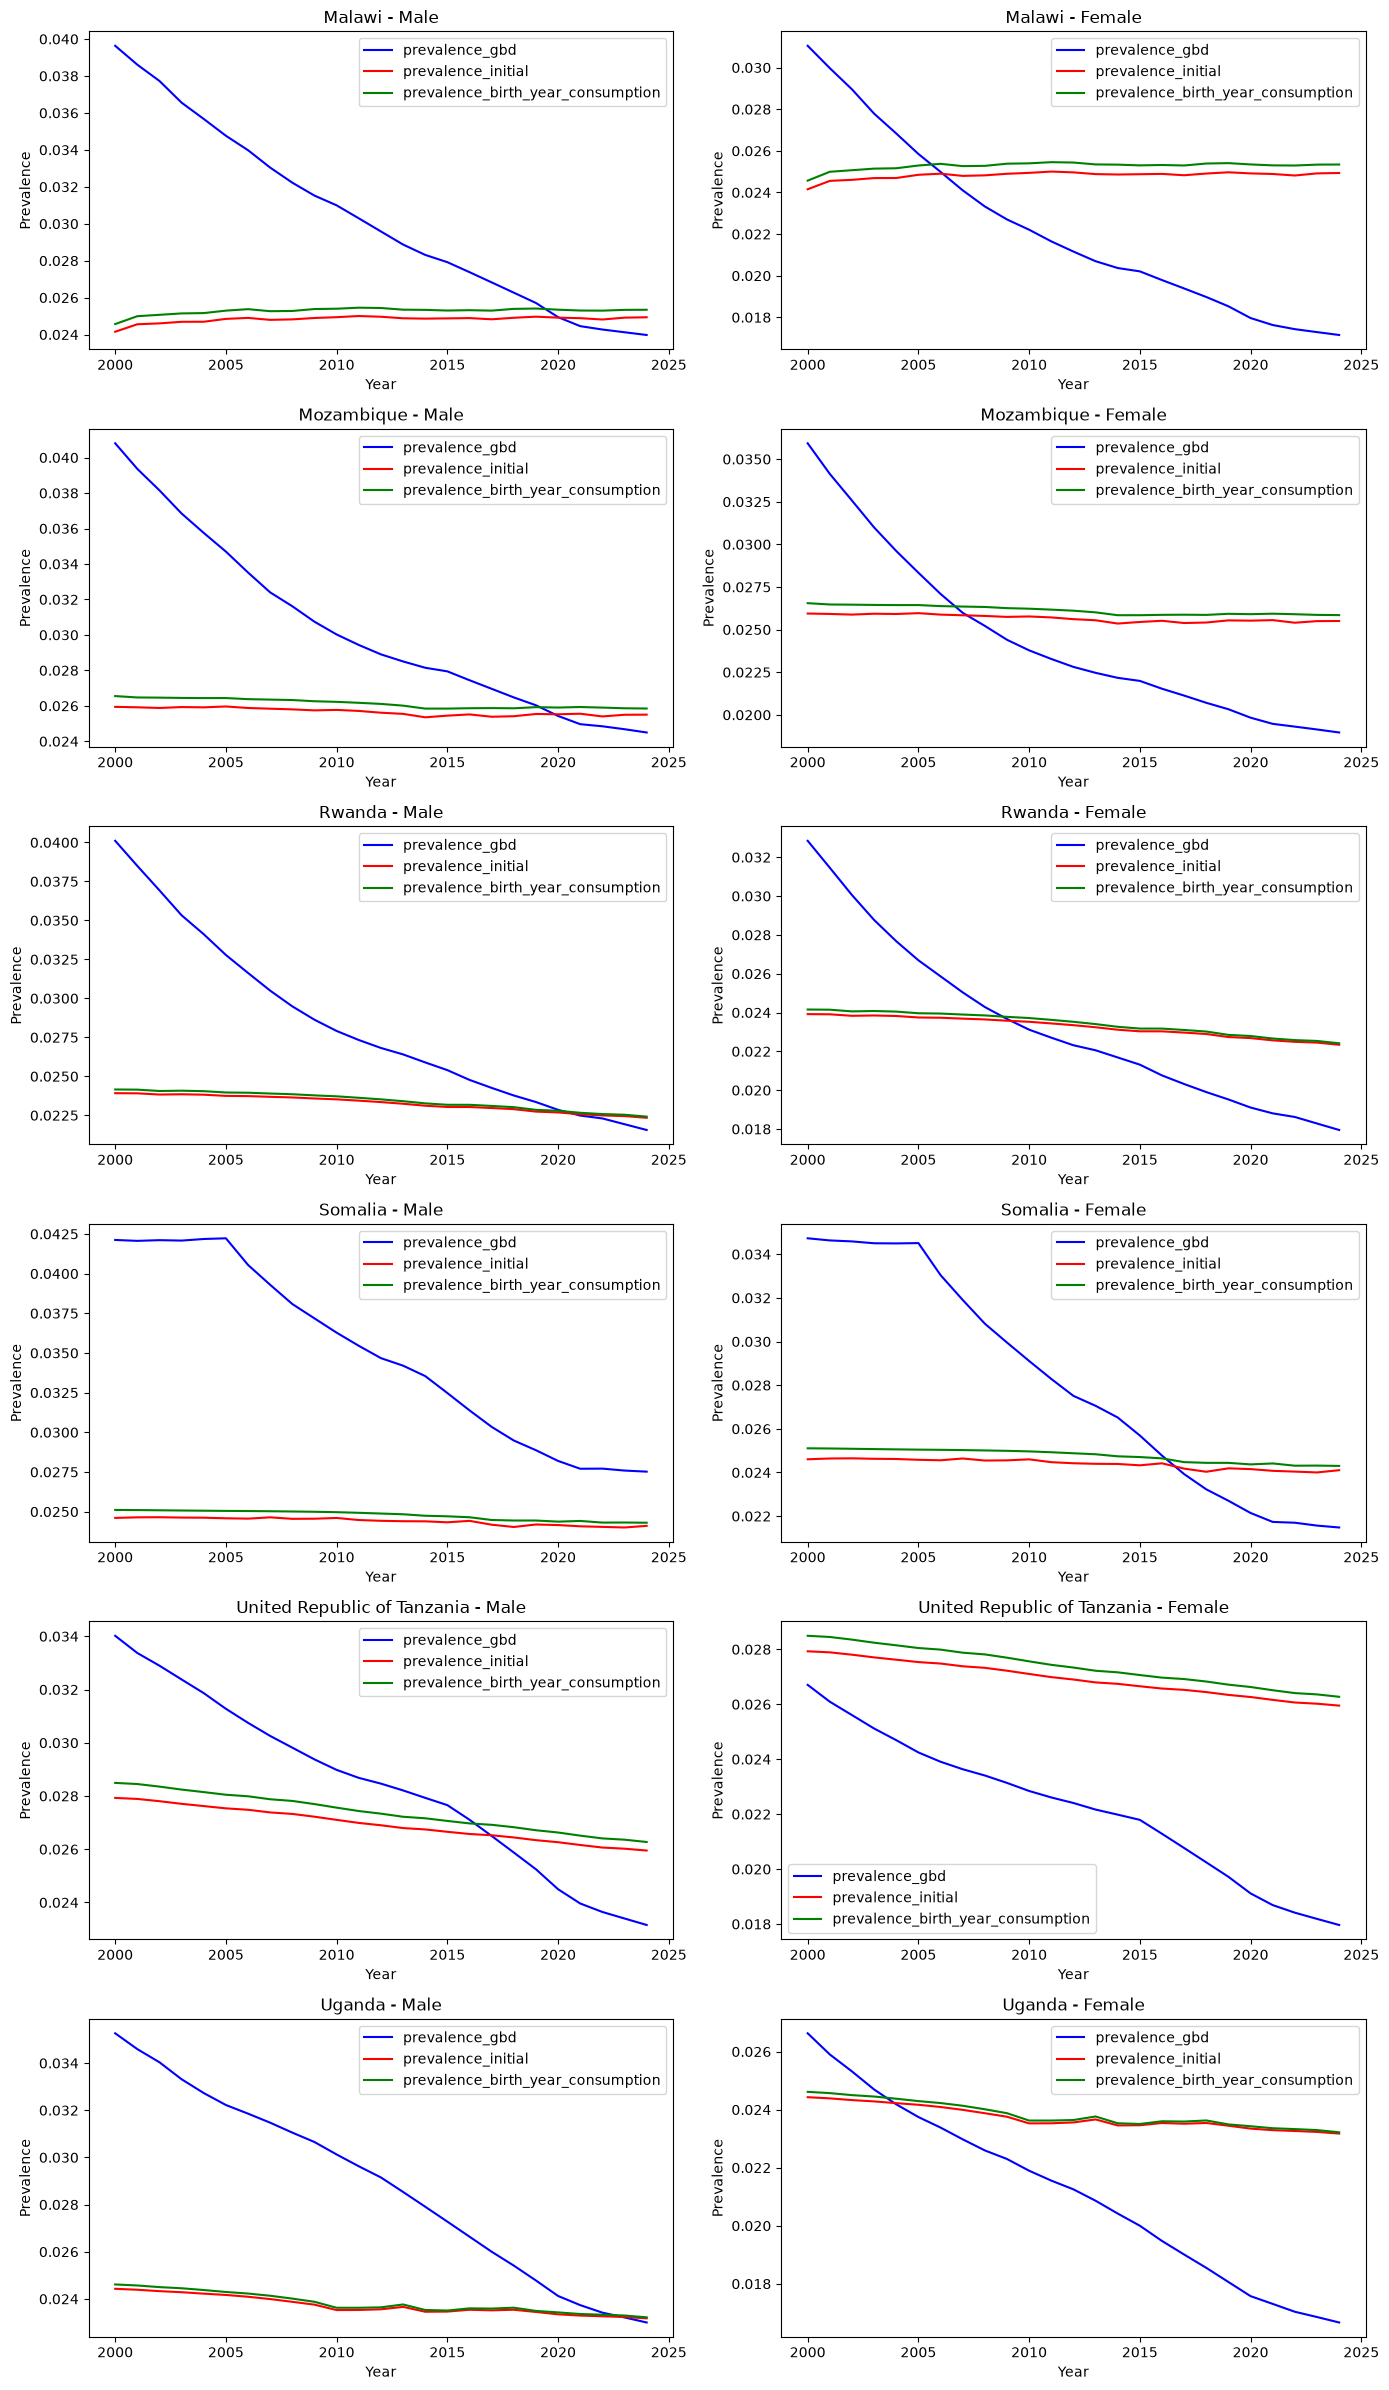

Creating plot pages:  38%|███▊      | 3/8 [00:06<00:10,  2.16s/it]

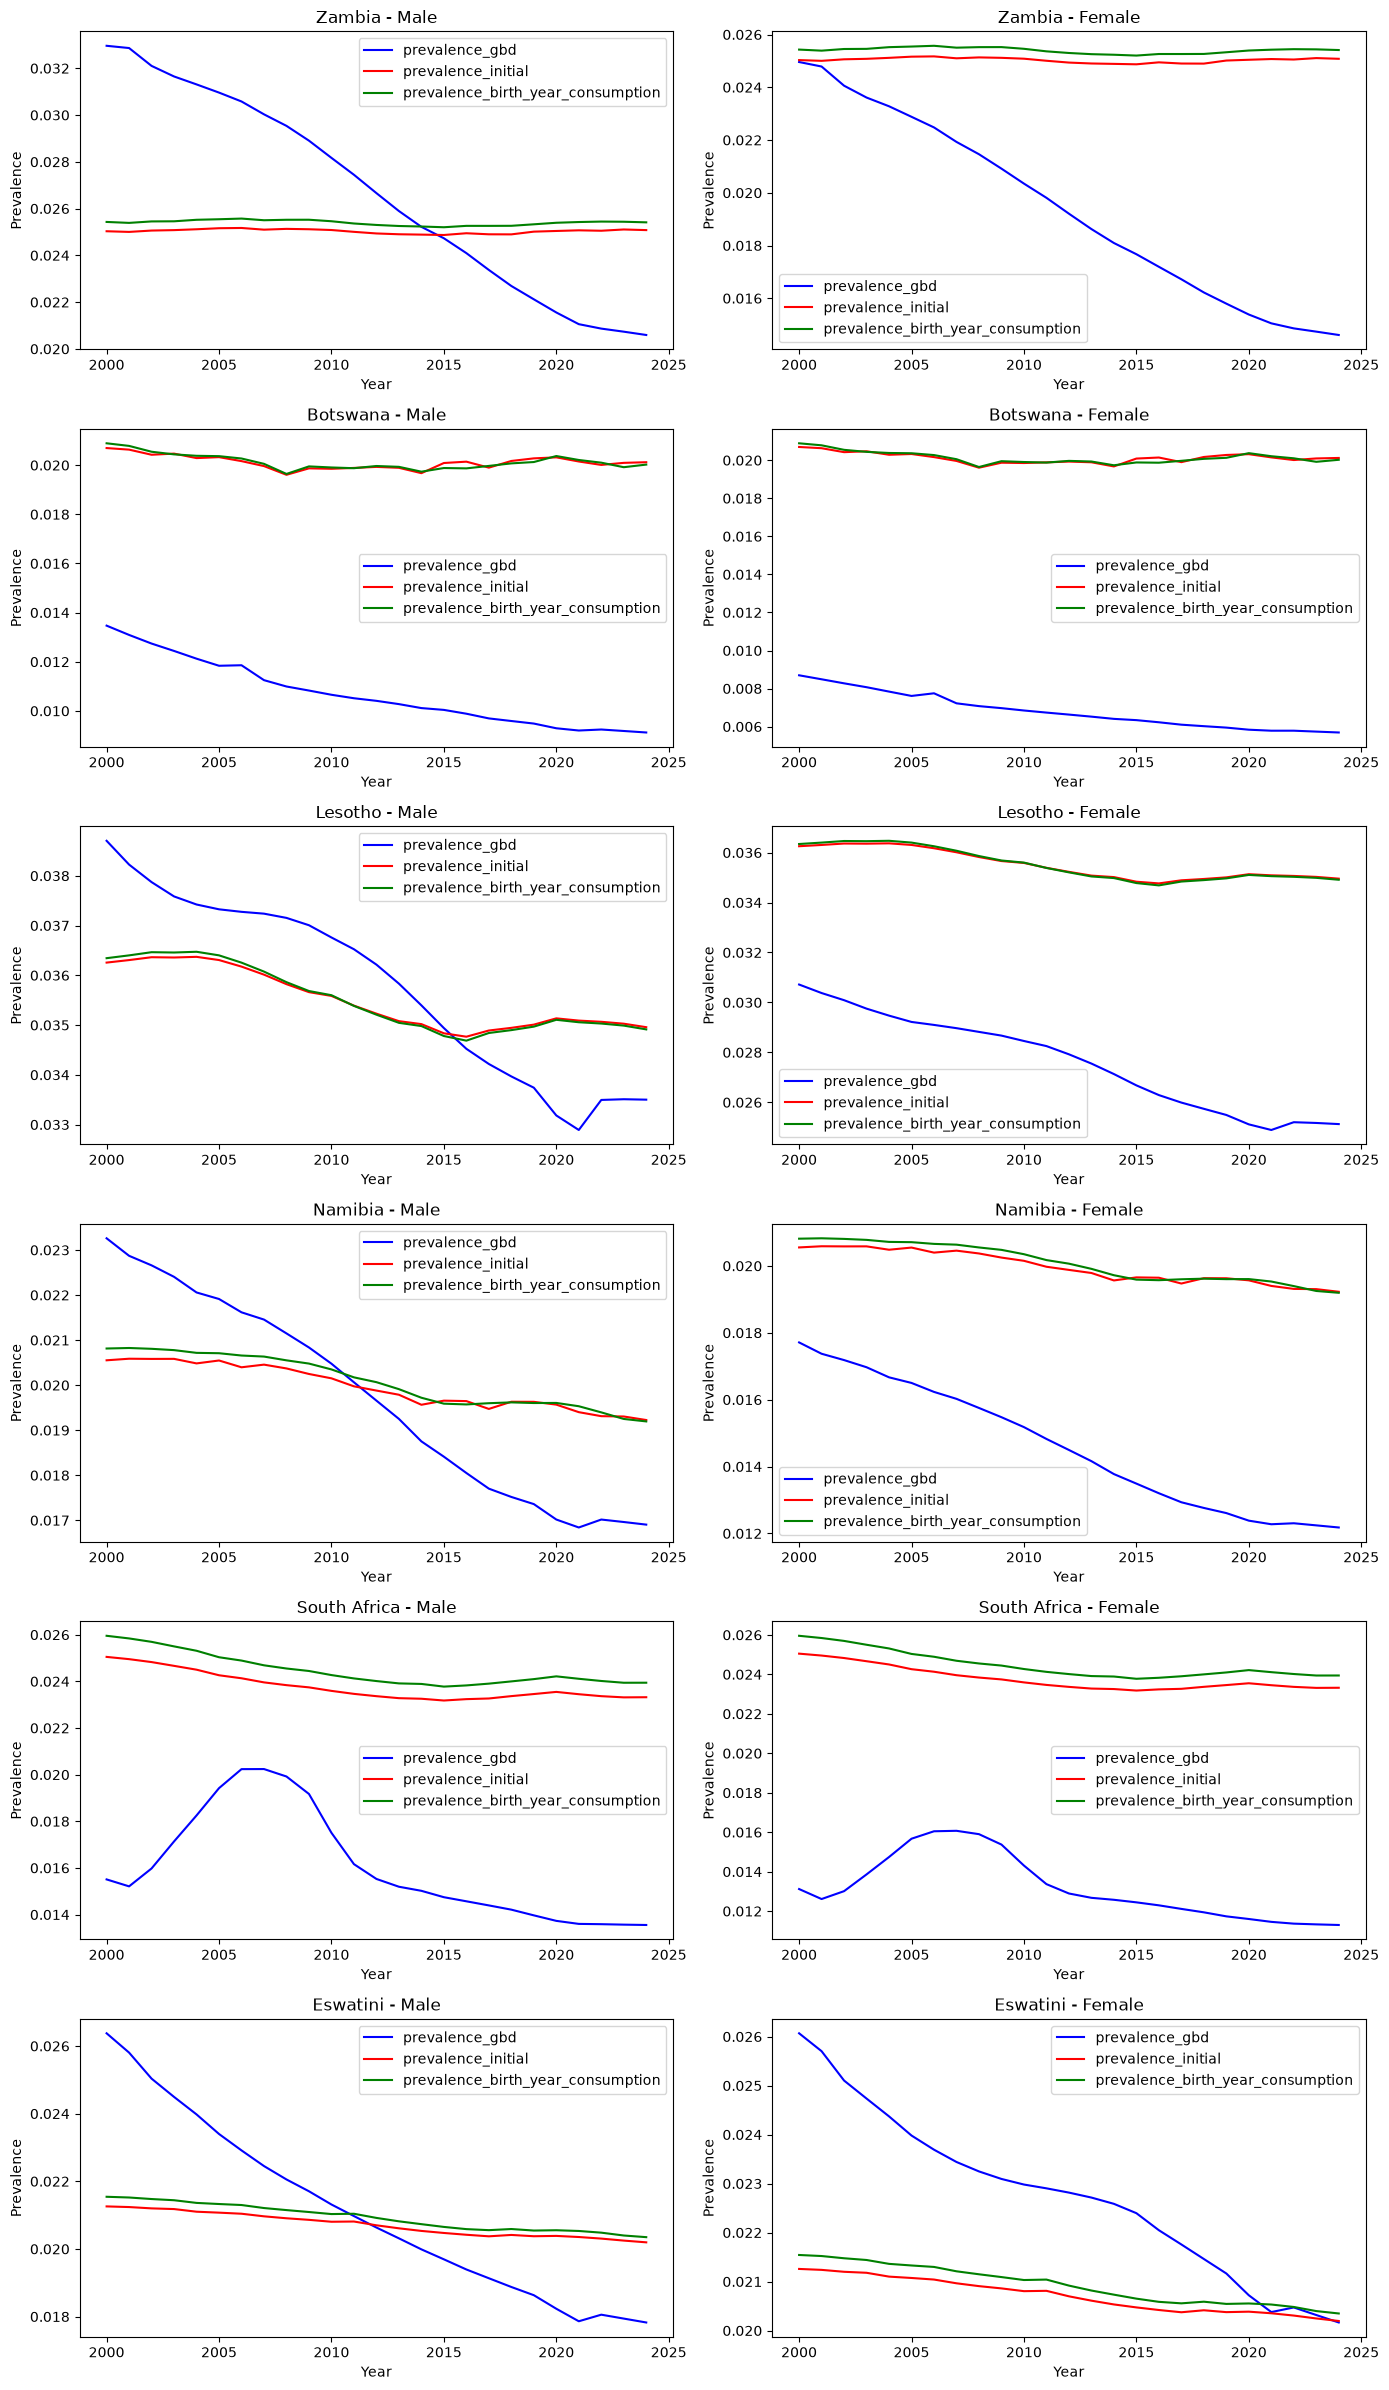

Creating plot pages:  50%|█████     | 4/8 [00:09<00:09,  2.28s/it]

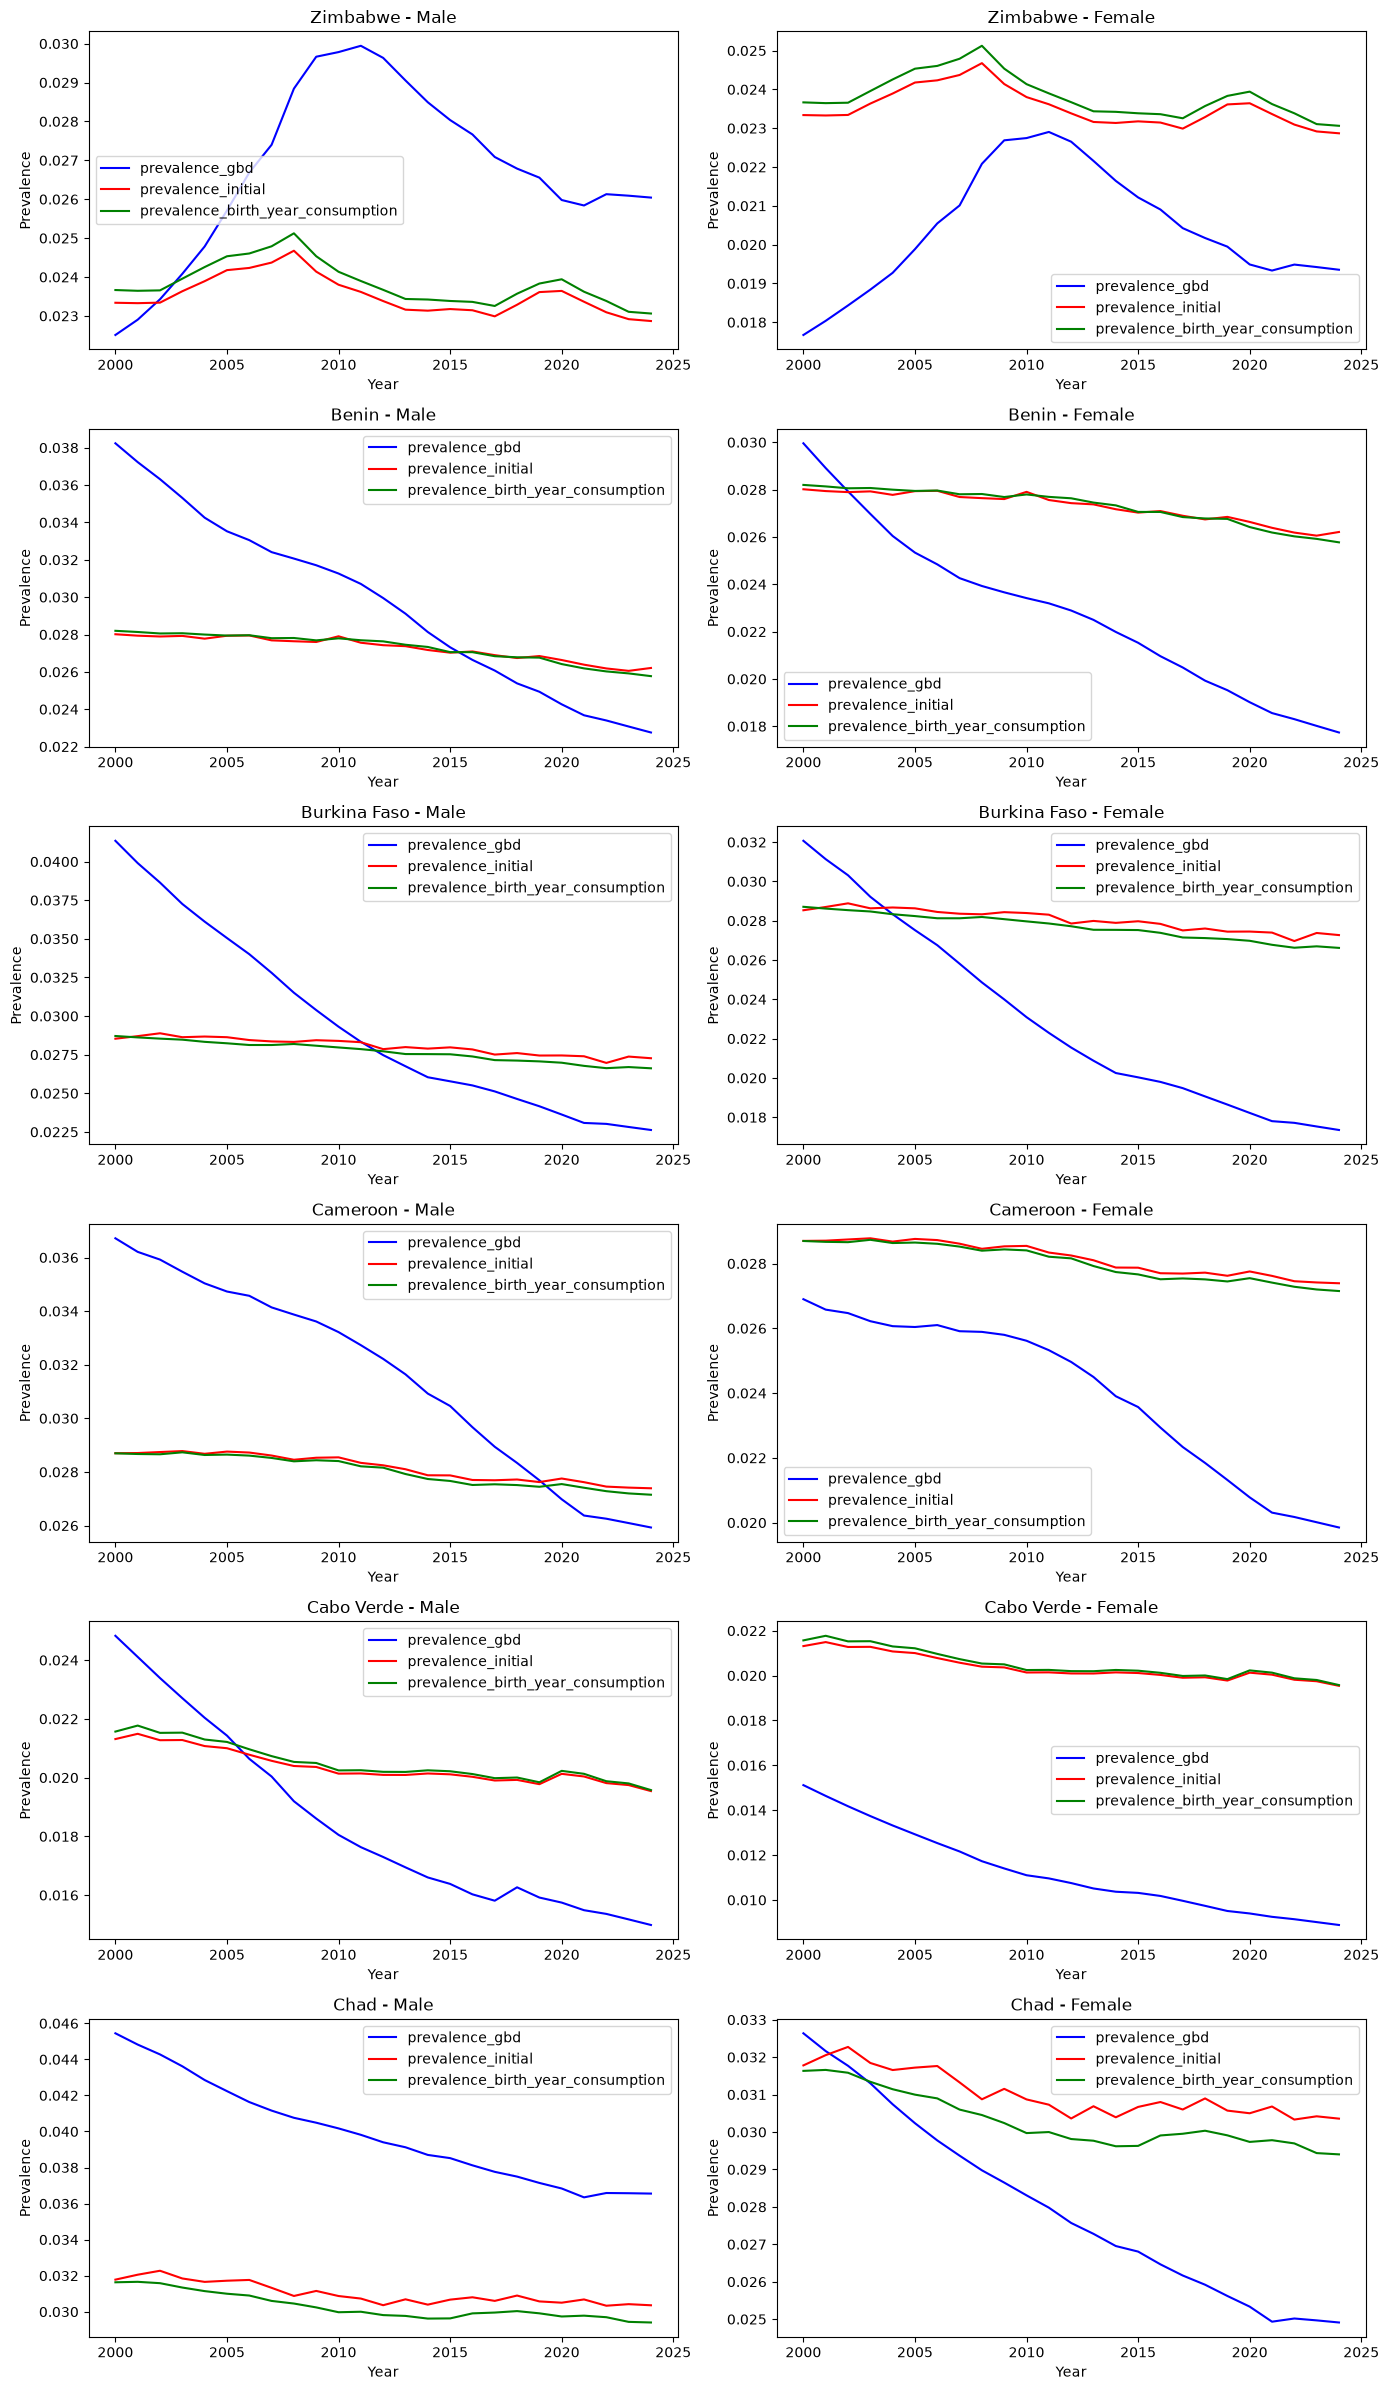

Creating plot pages:  62%|██████▎   | 5/8 [00:11<00:06,  2.22s/it]

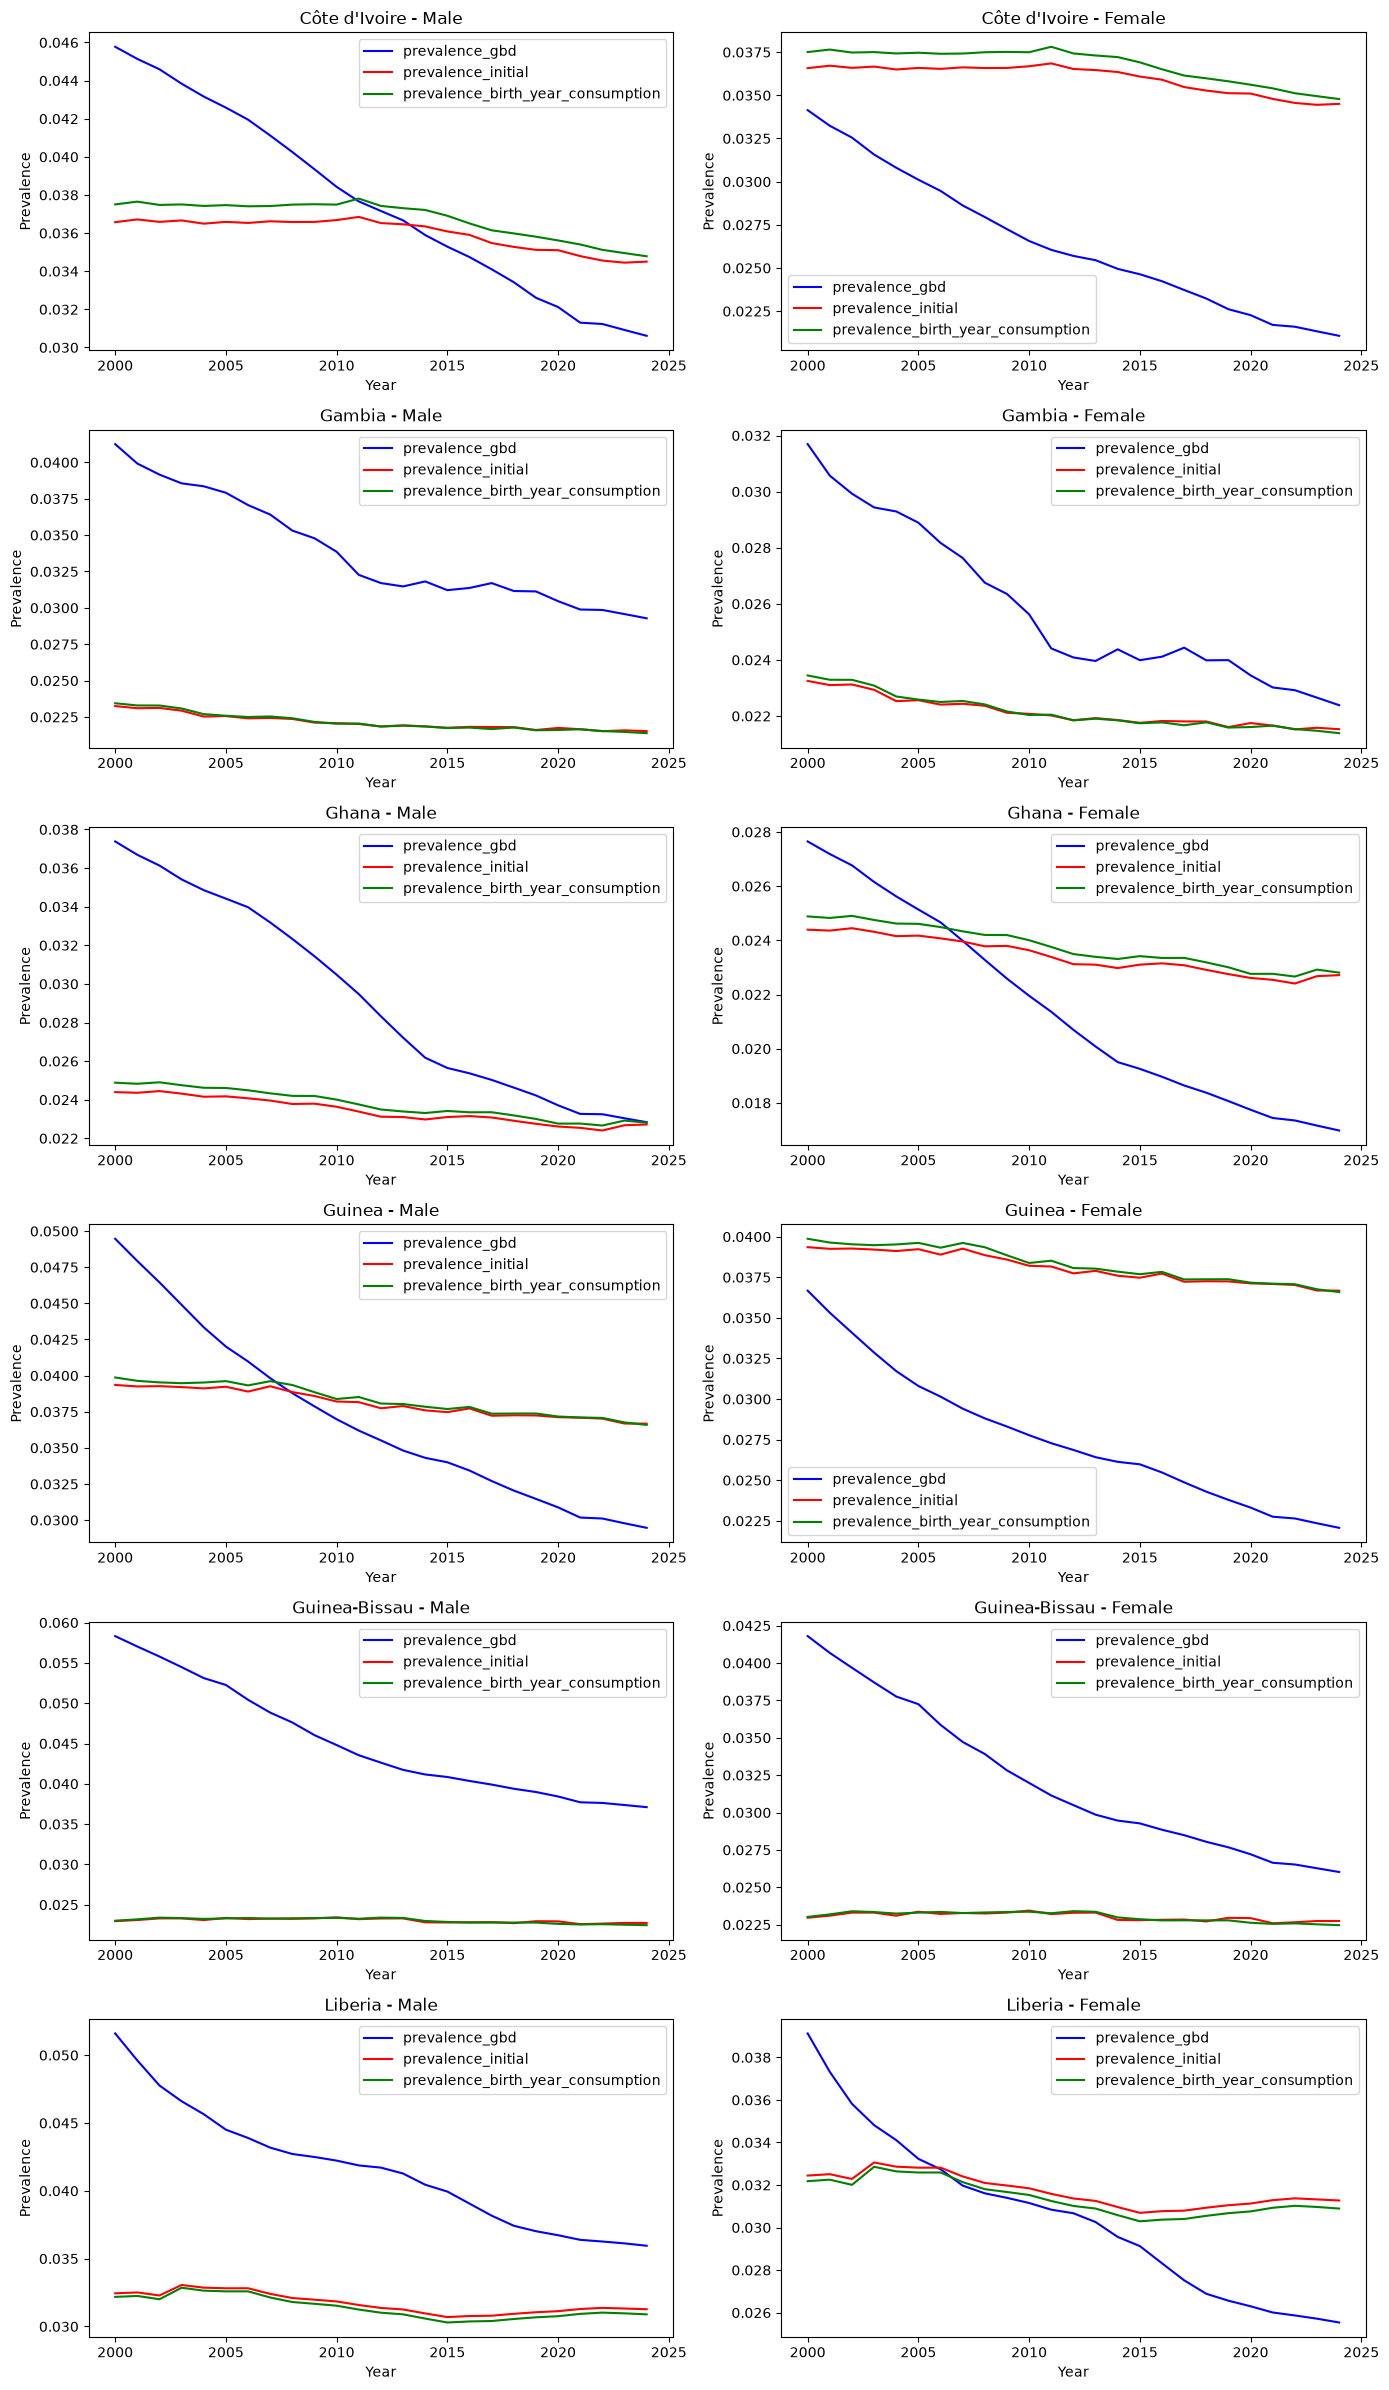

Creating plot pages:  75%|███████▌  | 6/8 [00:13<00:04,  2.25s/it]

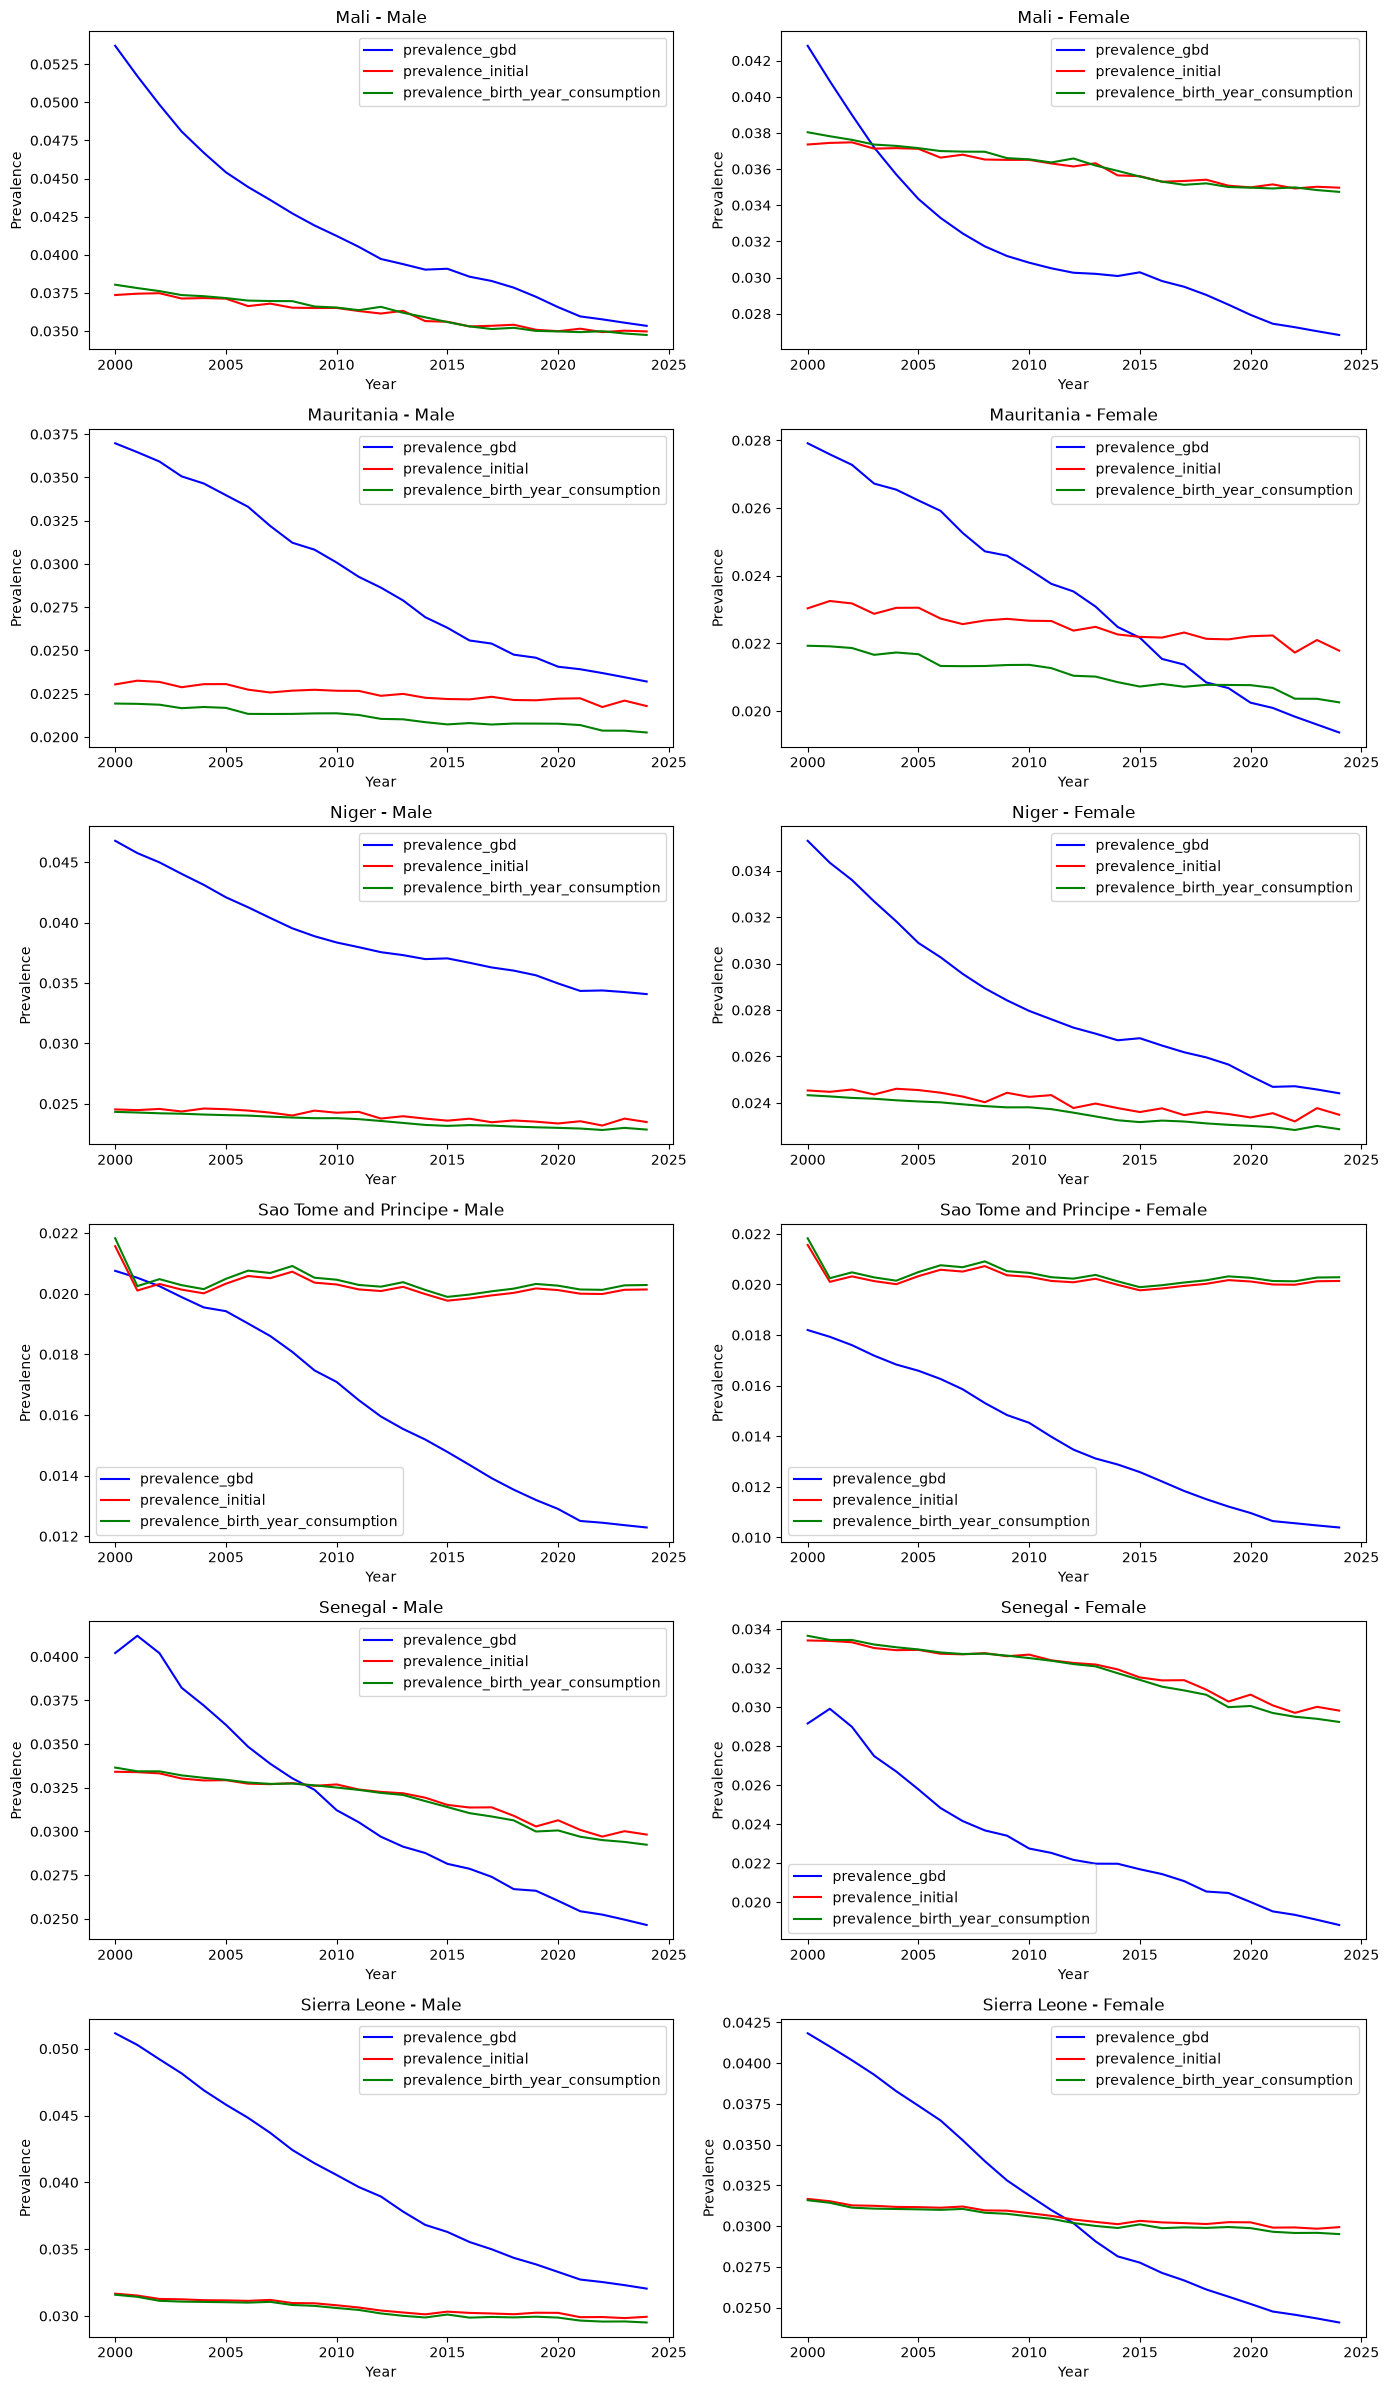

Creating plot pages:  88%|████████▊ | 7/8 [00:15<00:02,  2.28s/it]

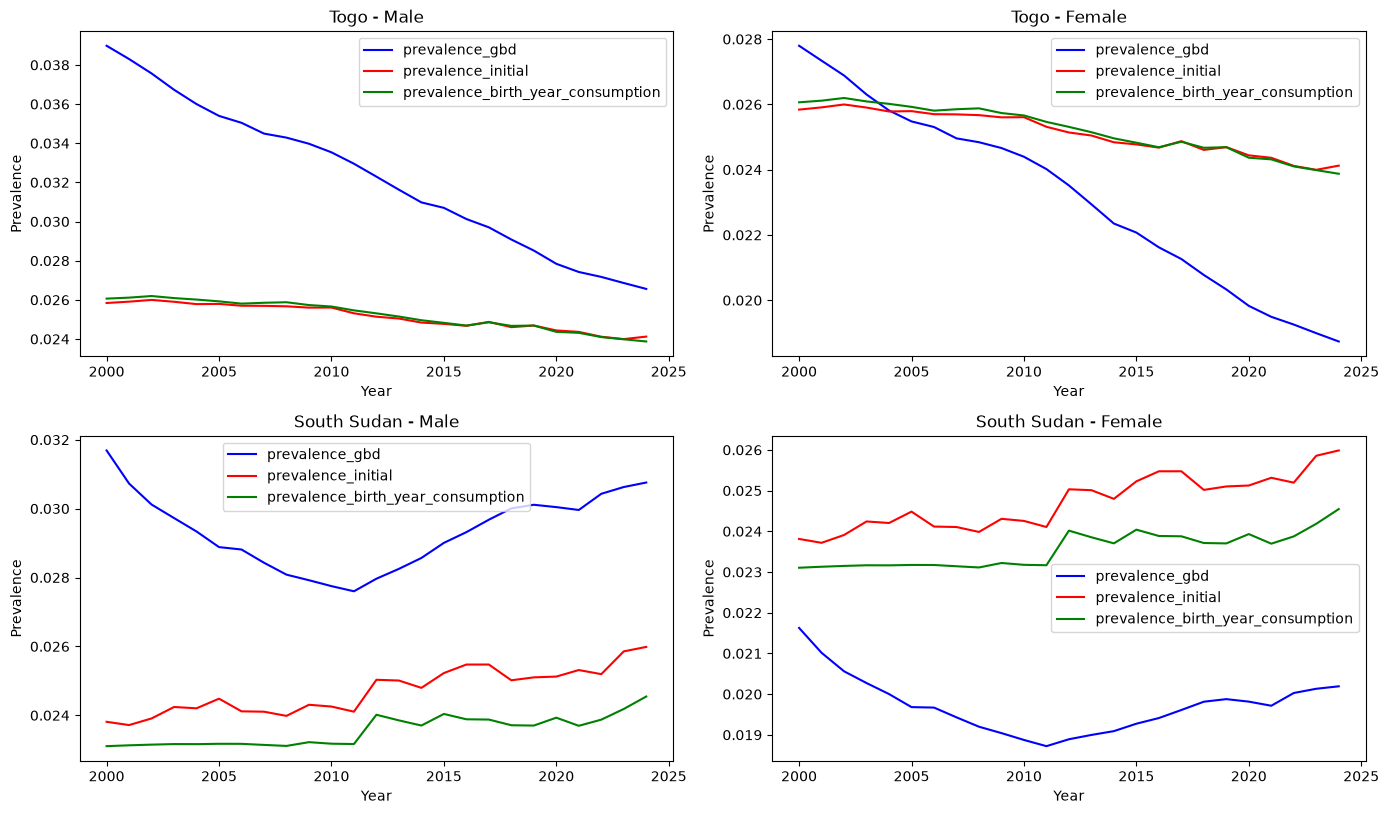

Creating plot pages: 100%|██████████| 8/8 [00:16<00:00,  2.08s/it]


In [12]:
# Plot time series for each location and save to pdf ###########################

color_dict = {
    "prevalence_gbd": "blue",
    "prevalence_initial": "red",
    "prevalence_birth_year_consumption": "green",
}
sex_id_dict = {1: "Male", 2: "Female"}

plot_df["Sex"] = plot_df["sex_id"].map(sex_id_dict)

plot_df = plot_df[plot_df["prevalence_birth_year_consumption"].notnull()].copy()

plot_locs = (
    plot_df[["location_id", "location_name"]]
    .drop_duplicates("location_id")
    .to_dict("records")
)

plot_path = f"{PLOT_OUTPUT}time_series_by_location_ssa.pdf"
sex_order = [(1, "Male"), (2, "Female")]
locations_per_page = 6

with PdfPages(plot_path) as pdf:
    page_starts = range(0, len(plot_locs), locations_per_page)
    for page_start in tqdm(page_starts, desc="Creating plot pages"):
        page_locs = plot_locs[page_start : page_start + locations_per_page]
        fig, axes = plt.subplots(
            nrows=locations_per_page,
            ncols=2,
            figsize=(14, 24),
            squeeze=False,
        )

        for row, location in enumerate(page_locs):
            location_id = location["location_id"]
            location_name = location["location_name"]
            for col_idx, (sex_id, sex_name) in enumerate(sex_order):
                ax = axes[row, col_idx]
                loc_sex_df = plot_df[
                    (plot_df["location_id"] == location_id)
                    & (plot_df["sex_id"] == sex_id)
                ]
                for prevalence_col, color in color_dict.items():
                    if prevalence_col in loc_sex_df.columns:
                        ax.plot(
                            loc_sex_df["year_id"],
                            loc_sex_df[prevalence_col],
                            label=prevalence_col,
                            color=color,
                        )
                ax.set_title(f"{location_name} - {sex_name}")
                ax.set_xlabel("Year")
                ax.set_ylabel("Prevalence")
                ax.legend()

        for row in range(len(page_locs), locations_per_page):
            for col_idx in range(2):
                axes[row, col_idx].set_visible(False)

        fig.tight_layout()
        pdf.savefig(fig)
        plt.show()
        plt.close(fig)

Aggregated covariates by country, with the GBD and model prediction lines overlaid on the non-logged panels

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/covariates_with_prediction_lines.pdf


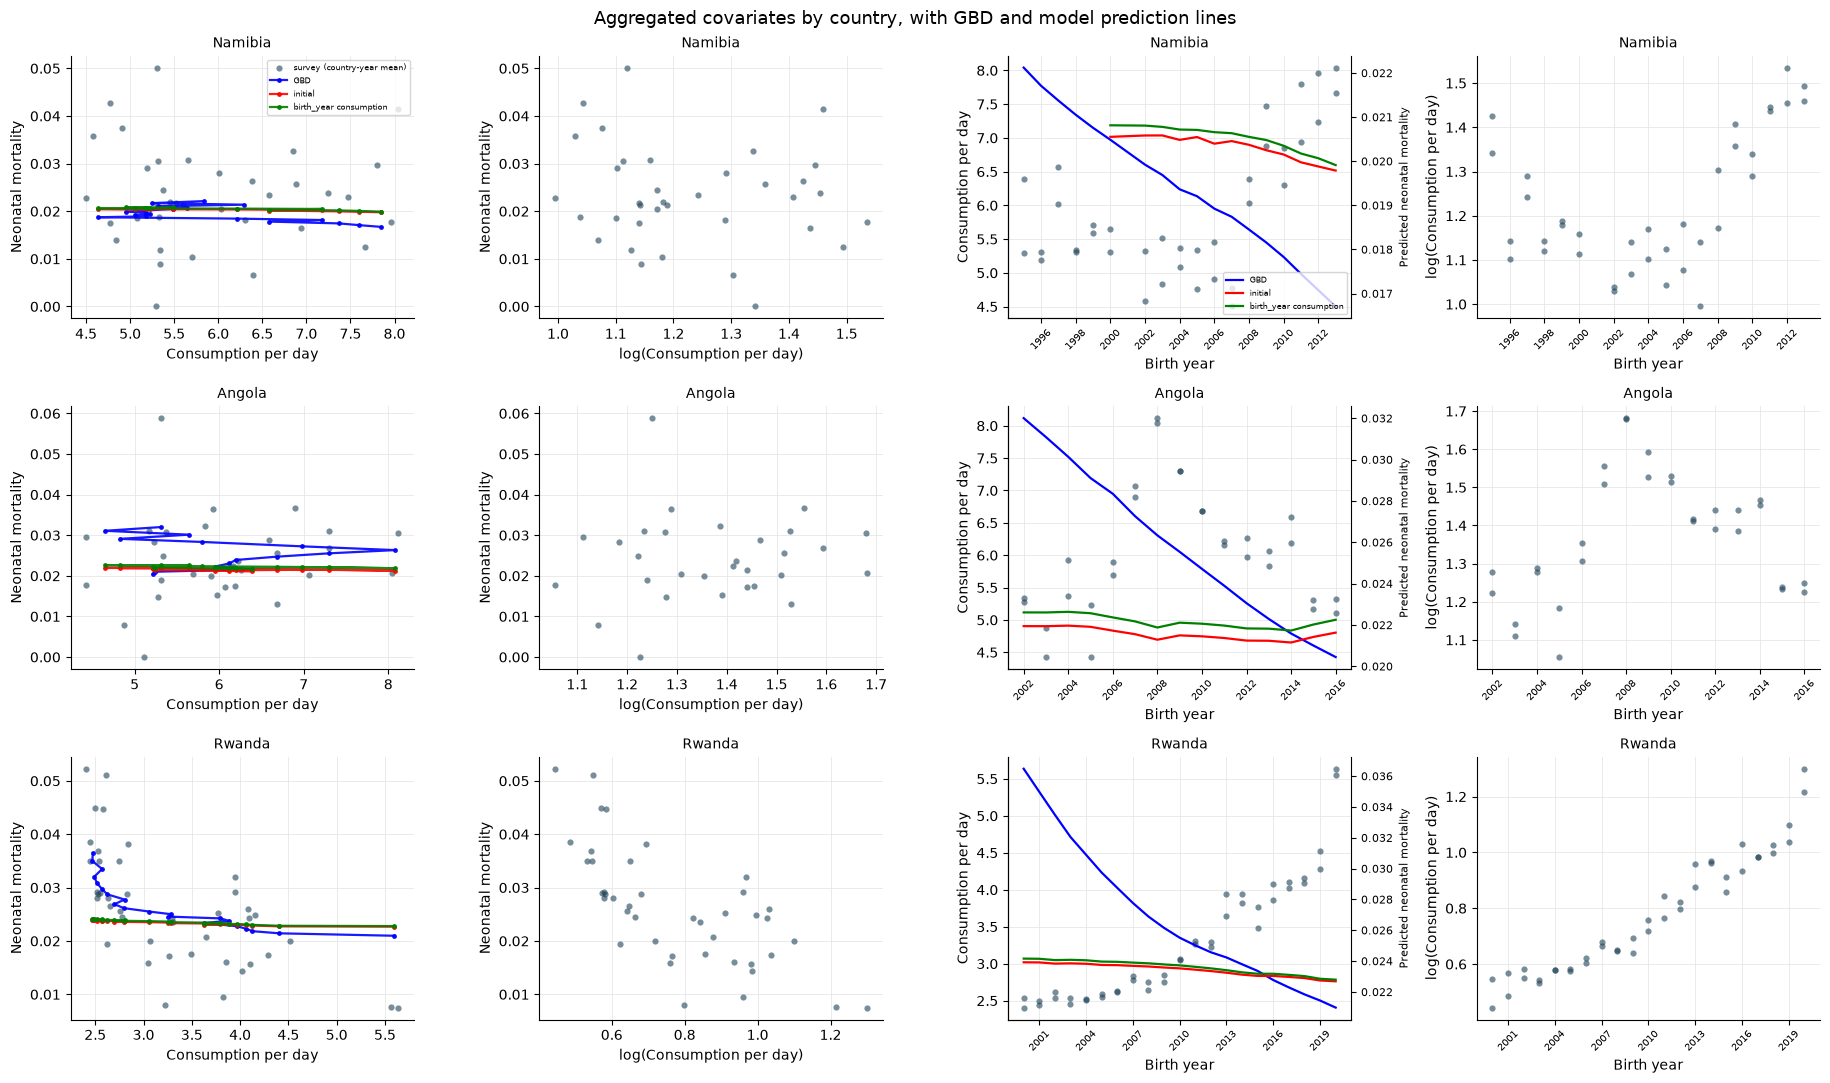

In [6]:
# Aggregated covariates by country, with fitted prediction lines ###############
# One row per country, four columns:
#   1. neonatal mortality vs. consumption_pd         (+ prediction lines)
#   2. neonatal mortality vs. log(consumption_pd)
#   3. consumption_pd vs. birth_year                 (+ prediction lines, twin axis)
#   4. log(consumption_pd) vs. birth_year
#
# Prediction lines are sex-averaged. In column 1 they are drawn parametrically:
# for each year, x = that year's mean consumption_pd in the training data and
# y = that year's predicted prevalence, so the lines are directly comparable to
# the survey scatter. Column 3 puts prevalence on a twin y axis because the left
# axis is consumption.


TRAINING_DATA_PATH = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/training_data/2026_09_13.01/data.parquet"

countries = ["Namibia", "Angola", "Rwanda"]
MIN_OBS = 25  # drop degenerate country-year-sex cells (set to 0 to keep every point)

PRED_COLS = {
    "prevalence_gbd": ("blue", "GBD"),
    "prevalence_initial": ("red", "initial"),
    "prevalence_birth_year_consumption": ("green", "birth_year consumption"),
}
POINT_COLOR = "#1f4257"

# Aggregate the training data to country / sex / birth-year ####################
train = pd.read_parquet(
    TRAINING_DATA_PATH,
    columns=[
        "ihme_loc_id",
        "sex_id",
        "birth_year",
        "consumption_pd",
        "neonatal_mortality",
    ],
)
train["log_consumption_pd"] = np.log(
    train["consumption_pd"].where(train["consumption_pd"] > 0)
)

df_agg = (
    train.groupby(["ihme_loc_id", "sex_id", "birth_year"])
    .agg(
        consumption_pd=("consumption_pd", "mean"),
        log_consumption_pd=("log_consumption_pd", "mean"),
        neonatal_mortality=("neonatal_mortality", "mean"),
        n_births=("neonatal_mortality", "size"),
    )
    .reset_index()
    .query("n_births >= @MIN_OBS")
    .merge(locs[["ihme_loc_id", "location_name"]], on="ihme_loc_id", how="left")
)

# Sex-averaged predictions, placed on the consumption axis by year #############
pred = (
    merged_df[merged_df["location_name"].isin(countries)]
    .groupby(["location_name", "year_id"], as_index=False)[list(PRED_COLS)]
    .mean()
)
cons_by_year = (
    df_agg.groupby(["location_name", "birth_year"], as_index=False)["consumption_pd"]
    .mean()
    .rename(columns={"birth_year": "year_id"})
)
pred = pred.merge(
    cons_by_year, on=["location_name", "year_id"], how="inner"
).sort_values("year_id")

# Plot ########################################################################
panel_specs = [
    (
        "consumption_pd",
        "neonatal_mortality",
        "Consumption per day",
        "Neonatal mortality",
        True,
    ),
    (
        "log_consumption_pd",
        "neonatal_mortality",
        "log(Consumption per day)",
        "Neonatal mortality",
        False,
    ),
    ("birth_year", "consumption_pd", "Birth year", "Consumption per day", True),
    (
        "birth_year",
        "log_consumption_pd",
        "Birth year",
        "log(Consumption per day)",
        False,
    ),
]

fig, axes = plt.subplots(
    nrows=len(countries),
    ncols=len(panel_specs),
    figsize=(4.6 * len(panel_specs), 11),
)
axes = np.atleast_2d(axes)

for row, country in enumerate(countries):
    subset = df_agg[df_agg["location_name"] == country]
    p = pred[pred["location_name"] == country]
    for col, (x_col, y_col, x_label, y_label, overlay) in enumerate(panel_specs):
        ax = axes[row, col]
        ax.scatter(
            subset[x_col],
            subset[y_col],
            color=POINT_COLOR,
            s=20,
            alpha=0.6,
            linewidths=0,
            zorder=1,
            label="survey (country-year mean)",
        )

        if overlay and len(p):
            if x_col == "consumption_pd":
                for pred_col, (color, label) in PRED_COLS.items():
                    ax.plot(
                        p["consumption_pd"],
                        p[pred_col],
                        color=color,
                        lw=1.6,
                        marker="o",
                        ms=2.5,
                        alpha=0.9,
                        zorder=3,
                        label=label,
                    )
            else:
                ax2 = ax.twinx()
                for pred_col, (color, label) in PRED_COLS.items():
                    ax2.plot(
                        p["year_id"],
                        p[pred_col],
                        color=color,
                        lw=1.6,
                        zorder=3,
                        label=label,
                    )
                ax2.set_ylabel("Predicted neonatal mortality", fontsize=8)
                ax2.tick_params(labelsize=8)
                ax2.spines["top"].set_visible(False)
                if row == 0:
                    ax2.legend(fontsize=6, loc="lower right")

        ax.set_title(country, fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, color="0.9", linewidth=0.6)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        if x_col == "birth_year":
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.tick_params(axis="x", rotation=45, labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=6, loc="upper right")

fig.suptitle(
    "Aggregated covariates by country, with GBD and model prediction lines",
    fontsize=13,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}covariates_with_prediction_lines.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()